# Challenge Sprint 4 — Classificação linear de `Energy_Class`

**Dataset:** Renewable Energy Production Dataset (2010–2020) — Kaggle
**Integrantes do grupo (nome completo e RM):**

| Nome completo | RM |
|---|---|
| Eduardo Barcelos De Carvalho Braziliano | 573274 |
| Julia Johanson Peniche Dias Da Silva | 572220 |
| Lucas Bomfim Leite | 570420 |

---
## Configuração
Bibliotecas, semente aleatória fixa (`SEED = 42`, garante reprodutibilidade) e origem do CSV.

**Importação do dataset:** o `pd.read_csv` lê o arquivo **direto pelo link raw do GitHub** (sem baixar e sem upload). O link está na variável `URL_CSV` da célula abaixo. Se o link falhar, o código usa automaticamente `dados/Renewable_Energy_Data.csv` local.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, classification_report)

import os
SEED = 42
URL_CSV = "https://raw.githubusercontent.com/lucasbomfim1207-ai/Sprint04_MLAM/refs/heads/main/dados/Renewable_Energy_Data.csv"
CAMINHO = "dados/Renewable_Energy_Data.csv"  # alternativa local
for pasta in ("figuras", "resultados"):
    os.makedirs(pasta, exist_ok=True)

---
# 01) Análise do dataset
## a) Carregamento
O dataset tem **1000 linhas × 11 colunas**, **sem valores nulos e sem duplicatas**. São 3 variáveis categóricas (`Region`, `Energy_Source`, `Season`), 7 numéricas e o alvo `Energy_Class` (High = 486, Medium = 336, Low = 178 → levemente desbalanceado; classe majoritária = 48,6%, que é o *baseline* a ser superado).

In [2]:
# 01) ANALISE DO DATASET
# a) Carregar
try:
    df = pd.read_csv(URL_CSV)
    print("Dataset carregado direto do link (GitHub raw).")
except Exception as e:
    print("Link indisponivel, usando arquivo local:", e)
    df = pd.read_csv(CAMINHO)
print("Shape:", df.shape)
print(df.dtypes)
print("Nulos:", df.isna().sum().sum(), "| Duplicados:", df.duplicated().sum())
print(df["Energy_Class"].value_counts())

Dataset carregado direto do link (GitHub raw).
Shape: (1000, 11)
Region                     object
Energy_Source              object
Temperature_C             float64
Wind_Speed_m_s            float64
Solar_Radiation_kWh_m2    float64
Rainfall_mm               float64
Season                     object
Efficiency_Ratio          float64
Lagged_Production_MWh     float64
Combined_Weather_Index    float64
Energy_Class               object
dtype: object
Nulos: 0 | Duplicados: 0
Energy_Class
High      486
Medium    336
Low       178
Name: count, dtype: int64


## b) Encoding da variável-alvo
`Energy_Class` é **ordinal** (Low < Medium < High), por isso foi usado um mapeamento ordenado: **Low = 0, Medium = 1, High = 2**. Essa escolha preserva a ordem natural das classes e permite calcular correlação com o alvo.

In [3]:
# b) Encoding da variavel-alvo (ordinal: Low < Medium < High)
mapa = {"Low": 0, "Medium": 1, "High": 2}
df["Energy_Class_enc"] = df["Energy_Class"].map(mapa)

num_cols = ["Temperature_C", "Wind_Speed_m_s", "Solar_Radiation_kWh_m2", "Rainfall_mm",
            "Efficiency_Ratio", "Lagged_Production_MWh", "Combined_Weather_Index"]
cat_cols = ["Region", "Energy_Source", "Season"]

## c) Matrizes de correlação
Foram construídas duas matrizes entre as features numéricas e `Energy_Class` codificada: **Pearson** (relações lineares, sensível a outliers) e **Spearman** (relações monotônicas, baseada em postos, robusta a outliers). Isso é necessário porque `Efficiency_Ratio` (assimetria ≈ 20) e `Combined_Weather_Index` (assimetria ≈ −19,5) têm caudas extremas.


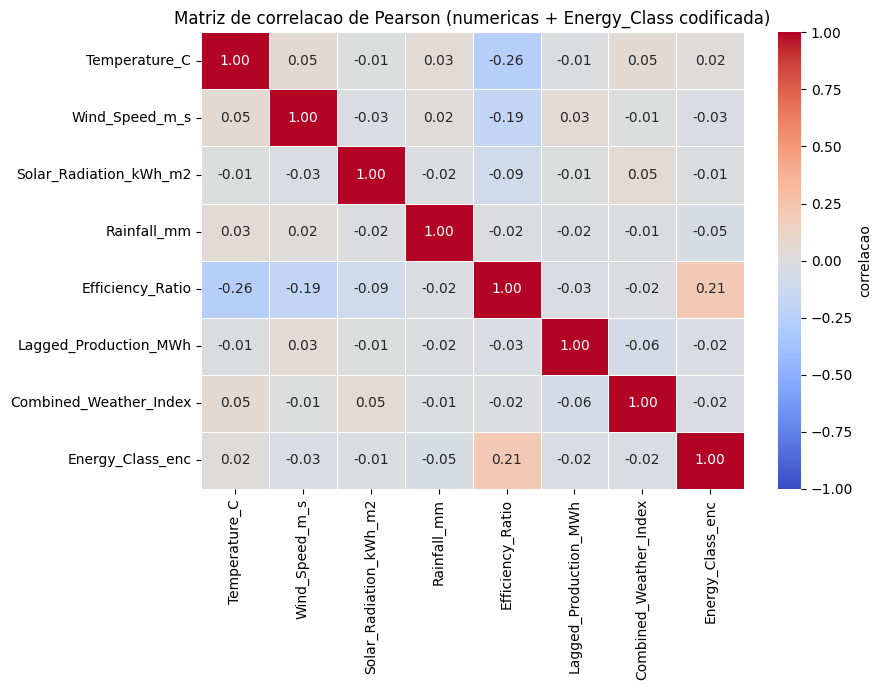

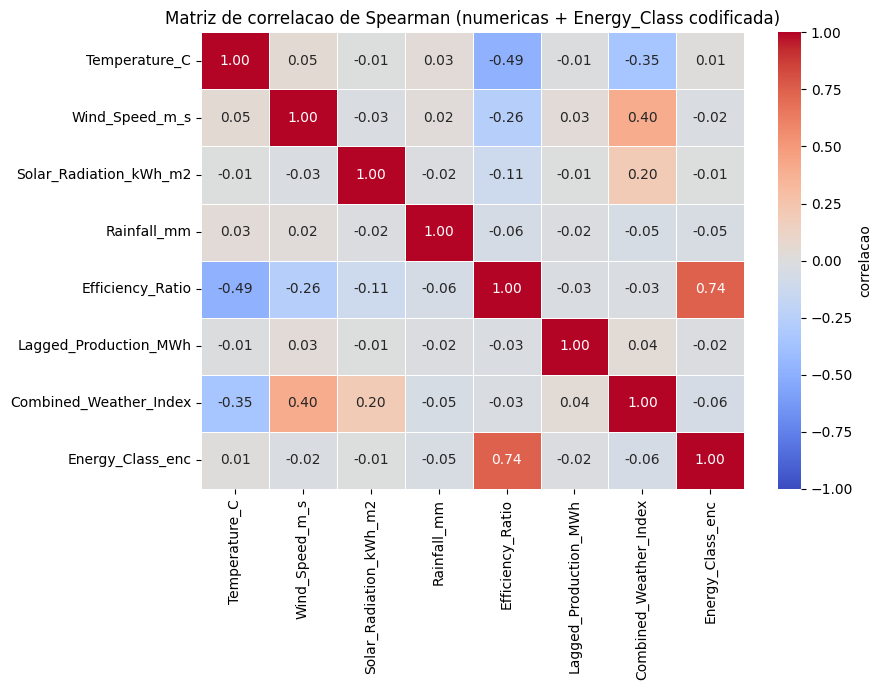

In [4]:
# c) Matrizes de correlacao
def heat(corr, titulo, arq, size=(9, 7)):
    plt.figure(figsize=size)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
                linewidths=.5, cbar_kws={"label": "correlacao"})
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(arq, dpi=150)
    plt.show()


num_y = df[num_cols + ["Energy_Class_enc"]]
corr_p = num_y.corr(method="pearson")
corr_s = num_y.corr(method="spearman")
heat(corr_p, "Matriz de correlacao de Pearson (numericas + Energy_Class codificada)", "figuras/01_correlacao_pearson.png")
heat(corr_s, "Matriz de correlacao de Spearman (numericas + Energy_Class codificada)", "figuras/02_correlacao_spearman.png")
corr_p.round(4).to_csv("resultados/correlacao_pearson.csv")
corr_s.round(4).to_csv("resultados/correlacao_spearman.csv")

### Matriz completa incluindo as variáveis categóricas (one-hot)
Para que **todas** as features do dataset sejam avaliadas, as categóricas foram expandidas em colunas binárias.

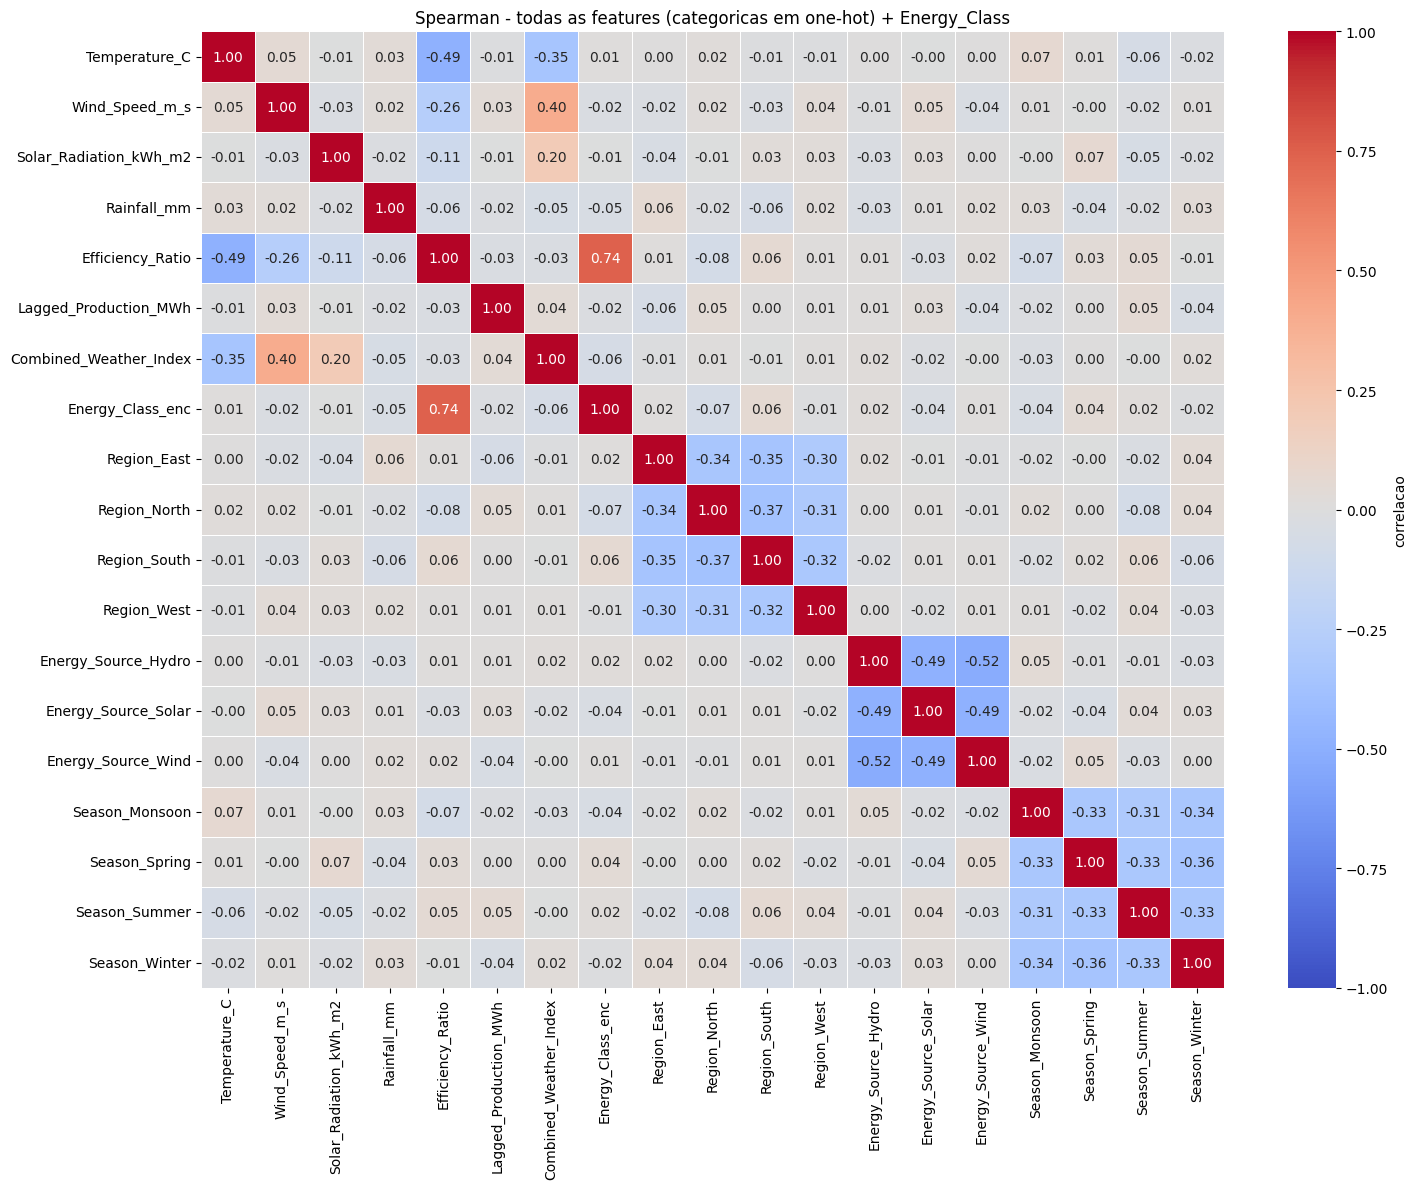


Correlacao com o alvo:
                         Pearson  Spearman  |Spearman|
Efficiency_Ratio          0.211     0.743       0.743
Combined_Weather_Index   -0.025    -0.060       0.060
Rainfall_mm              -0.046    -0.046       0.046
Wind_Speed_m_s           -0.027    -0.024       0.024
Lagged_Production_MWh    -0.024    -0.023       0.023
Temperature_C             0.018     0.010       0.010
Solar_Radiation_kWh_m2   -0.008    -0.006       0.006

Assimetria (skew):
 Temperature_C              0.01
Wind_Speed_m_s            -0.01
Solar_Radiation_kWh_m2    -0.05
Rainfall_mm                0.07
Efficiency_Ratio          20.39
Lagged_Production_MWh      0.07
Combined_Weather_Index   -19.51
dtype: float64

Correlacao categoricas (one-hot) x alvo (Spearman):
 Efficiency_Ratio          0.743
Region_North             -0.066
Combined_Weather_Index   -0.060
Region_South              0.057
Rainfall_mm              -0.046
Season_Monsoon           -0.045
Season_Spring             0.041
Energ

In [5]:
# Matriz completa com categoricas (one-hot) para avaliar todas as features
df_oh = pd.get_dummies(df.drop(columns="Energy_Class"), columns=cat_cols).astype(float)
corr_full = df_oh.corr(method="spearman")
heat(corr_full, "Spearman - todas as features (categoricas em one-hot) + Energy_Class",
     "figuras/03_correlacao_spearman_completa.png", (15, 12))
corr_full.round(4).to_csv("resultados/correlacao_spearman_completa.csv")

tab_corr = pd.DataFrame({"Pearson": corr_p["Energy_Class_enc"], "Spearman": corr_s["Energy_Class_enc"]}).drop("Energy_Class_enc")
tab_corr["|Spearman|"] = tab_corr["Spearman"].abs()
tab_corr = tab_corr.sort_values("|Spearman|", ascending=False)
tab_corr.round(4).to_csv("resultados/correlacao_com_alvo.csv")
print("\nCorrelacao com o alvo:\n", tab_corr.round(3))
print("\nAssimetria (skew):\n", df[num_cols].skew().round(2))
print("\nCorrelacao categoricas (one-hot) x alvo (Spearman):\n",
      corr_full["Energy_Class_enc"].drop("Energy_Class_enc").sort_values(key=abs, ascending=False).round(3).head(8))

### Por que Pearson e Spearman divergem tanto em `Efficiency_Ratio`?
Pearson = **0,21** contra Spearman = **0,74**. A cauda longa (poucos valores até ~16.000, contra mediana ≈ 150) distorce o coeficiente de Pearson, mas a *ordem* dos valores é muito informativa sobre a classe: a mediana é ≈ 32 em Low, ≈ 102 em Medium e ≈ 225 em High. Em escala logarítmica a relação fica clara e quase linear.


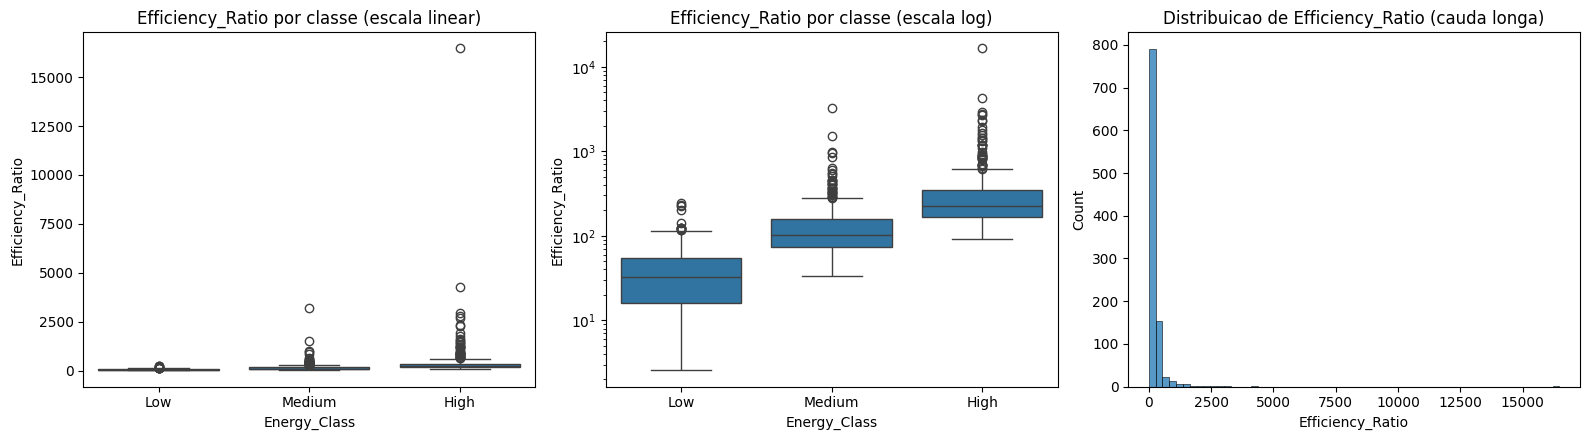

In [6]:
# Evidencia visual: outliers distorcem Pearson do Efficiency_Ratio
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=df, x="Energy_Class", y="Efficiency_Ratio", order=["Low", "Medium", "High"], ax=ax[0])
ax[0].set_title("Efficiency_Ratio por classe (escala linear)")
sns.boxplot(data=df, x="Energy_Class", y="Efficiency_Ratio", order=["Low", "Medium", "High"], ax=ax[1])
ax[1].set_yscale("log")
ax[1].set_title("Efficiency_Ratio por classe (escala log)")
sns.histplot(df["Efficiency_Ratio"], bins=60, ax=ax[2])
ax[2].set_title("Distribuicao de Efficiency_Ratio (cauda longa)")
plt.tight_layout()
plt.savefig("figuras/04_efficiency_outliers.png", dpi=150)
plt.show()

### Transformações para reduzir o efeito dos outliers
`log(Efficiency_Ratio)` (sempre positivo) e log com sinal em `Combined_Weather_Index`. Após o log, o **Pearson com o alvo sobe de 0,21 para 0,73**, confirmando que o problema era a escala e não a ausência de relação. São transformações aplicadas linha a linha, portanto **não causam vazamento de dados**.

In [7]:
# Transformacoes (reduzem o efeito dos outliers; sao funcoes linha a linha, logo sem vazamento)
df["log_Efficiency_Ratio"] = np.log(df["Efficiency_Ratio"])
df["slog_Combined_Weather_Index"] = np.sign(df["Combined_Weather_Index"]) * np.log1p(df["Combined_Weather_Index"].abs())
print("Pearson alvo x log_Efficiency_Ratio:", round(df["log_Efficiency_Ratio"].corr(df["Energy_Class_enc"]), 3))

Pearson alvo x log_Efficiency_Ratio: 0.734


## d) Seleção de features: subconjunto ou todas?

**Leitura da matriz de correlação**

1. **Só `Efficiency_Ratio` se relaciona com o alvo** (Spearman 0,74). Todas as demais têm |ρ| ≤ 0,06 — incluindo as categóricas em one-hot (|ρ| ≤ 0,07).
2. **Multicolinearidade é baixa**: a maior correlação entre features é |ρ| = 0,49 (`Temperature_C` × `Efficiency_Ratio`), bem abaixo de 0,9. Portanto **não há redundância** que obrigue a descartar features por duplicidade.
3. Mas há um alerta: `Temperature_C`, `Wind_Speed_m_s` e `Solar_Radiation_kWh_m2` se correlacionam com `Efficiency_Ratio` (−0,49, −0,26, −0,11). Isso indica que o *Efficiency_Ratio* depende do clima, e que o clima pode ajudar a "corrigir" a leitura dele mesmo sem ter correlação marginal com o alvo.

Como a correlação marginal sozinha pode enganar, **a decisão foi verificada empiricamente** com validação cruzada estratificada repetida (5 folds × 3 repetições) usando regressão logística, comparando conjuntos candidatos e fazendo ablação (remover uma feature por vez).

In [8]:
# d) Selecao de features: validacao cruzada repetida (5 folds x 3) com regressao logistica
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
y_all = df["Energy_Class_enc"]
todas_num = ["log_Efficiency_Ratio", "Temperature_C", "Wind_Speed_m_s", "Solar_Radiation_kWh_m2",
             "Rainfall_mm", "Lagged_Production_MWh", "slog_Combined_Weather_Index"]


def cv_score(nums, cats=()):
    trans = [("n", StandardScaler(), list(nums))]
    if cats:
        trans.append(("c", OneHotEncoder(), list(cats)))
    pipe = Pipeline([("p", ColumnTransformer(trans)), ("m", LogisticRegression(max_iter=5000))])
    s = cross_val_score(pipe, df[list(nums) + list(cats)], y_all, cv=cv)
    return s.mean(), s.std()


FEATURES = ["log_Efficiency_Ratio", "Temperature_C", "Wind_Speed_m_s", "Solar_Radiation_kWh_m2"]
brutas = ["Efficiency_Ratio", "Temperature_C", "Wind_Speed_m_s", "Solar_Radiation_kWh_m2",
          "Rainfall_mm", "Lagged_Production_MWh", "Combined_Weather_Index"]
opcoes = [
    ("Baseline (classe majoritaria)", None, ()),
    ("Somente Efficiency_Ratio bruto (maior |r| de Pearson)", ["Efficiency_Ratio"], ()),
    ("Somente log(Efficiency_Ratio)", ["log_Efficiency_Ratio"], ()),
    ("Todas as numericas brutas (sem transformacao)", brutas, ()),
    ("Todas as numericas (com log)", todas_num, ()),
    ("Todas as numericas (com log) + categoricas", todas_num, cat_cols),
    ("Subconjunto selecionado (4 features)", FEATURES, ()),
]
linhas = []
for nome, cols, cats in opcoes:
    if cols is None:
        linhas.append((nome, 0, y_all.value_counts(normalize=True).max(), 0.0))
        continue
    m, s = cv_score(cols, cats)
    linhas.append((nome, len(cols) + len(cats), m, s))
tab_sel = pd.DataFrame(linhas, columns=["Conjunto de features", "N features", "Acuracia CV (media)", "Desvio"])
tab_sel.round(4).to_csv("resultados/comparacao_selecao_features.csv", index=False)
print("\nSelecao de features (CV 5x3):\n", tab_sel.round(4).to_string(index=False))


Selecao de features (CV 5x3):
                                  Conjunto de features  N features  Acuracia CV (media)  Desvio
                        Baseline (classe majoritaria)           0               0.4860  0.0000
Somente Efficiency_Ratio bruto (maior |r| de Pearson)           1               0.7593  0.0263
                        Somente log(Efficiency_Ratio)           1               0.7663  0.0238
        Todas as numericas brutas (sem transformacao)           7               0.7907  0.0295
                         Todas as numericas (com log)           7               0.9113  0.0197
           Todas as numericas (com log) + categoricas          10               0.9067  0.0250
                 Subconjunto selecionado (4 features)           4               0.9167  0.0198


### Ablação: o que acontece ao remover cada feature


Ablacao (referencia = todas numericas):
            Feature removida  Queda de acuracia
       log_Efficiency_Ratio             0.4307
              Temperature_C             0.1440
             Wind_Speed_m_s             0.0533
     Solar_Radiation_kWh_m2             0.0100
slog_Combined_Weather_Index            -0.0010
                Rainfall_mm            -0.0017
      Lagged_Production_MWh            -0.0023


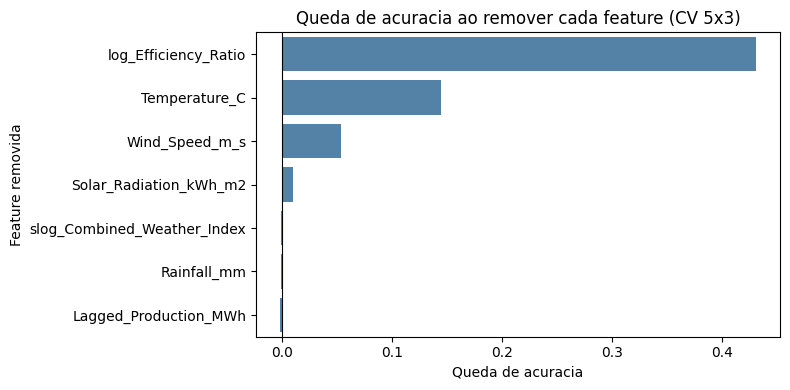

In [9]:
# Ablacao: efeito de remover cada feature do conjunto completo
ref = cv_score(todas_num)[0]
abl = [(f, ref - cv_score([c for c in todas_num if c != f])[0]) for f in todas_num]
tab_abl = pd.DataFrame(abl, columns=["Feature removida", "Queda de acuracia"]).sort_values("Queda de acuracia", ascending=False)
tab_abl.round(4).to_csv("resultados/ablacao_features.csv", index=False)
print("\nAblacao (referencia = todas numericas):\n", tab_abl.round(4).to_string(index=False))
plt.figure(figsize=(8, 4))
sns.barplot(data=tab_abl, y="Feature removida", x="Queda de acuracia", color="steelblue")
plt.axvline(0, color="k", lw=.8)
plt.title("Queda de acuracia ao remover cada feature (CV 5x3)")
plt.tight_layout()
plt.savefig("figuras/05_ablacao_features.png", dpi=150)
plt.show()

### Decisão (justificativa técnica)

**Conclusão: é mais apropriado usar um subconjunto de 4 features** — `log_Efficiency_Ratio`, `Temperature_C`, `Wind_Speed_m_s` e `Solar_Radiation_kWh_m2`.

* **Descartadas:** `Rainfall_mm`, `Lagged_Production_MWh`, `Combined_Weather_Index` e as três categóricas (`Region`, `Energy_Source`, `Season`). Todas têm correlação com o alvo ≈ 0, e removê-las não reduz a acurácia (a ablação mostra variações entre −0,2 e −0,1 p.p., isto é, ligeira *melhora*). Adicioná-las só introduz ruído e dimensionalidade (as categóricas viram 11 colunas one-hot), com acurácia CV de 0,9067 contra 0,9167 do subconjunto.
* **Mantidas além de `Efficiency_Ratio`:** `Temperature_C` e `Wind_Speed_m_s` têm correlação ≈ 0 com o alvo, **porém a ablação mostra que removê-las derruba a acurácia em 14,4 p.p. e 5,3 p.p.** Isso ocorre porque elas se correlacionam com `Efficiency_Ratio` (efeito supressor): o modelo usa o clima para interpretar o nível de eficiência. `Solar_Radiation_kWh_m2` contribui ~1 p.p. e foi mantida pelo mesmo motivo.
* **Lição:** selecionar apenas por |correlação com o alvo| deixaria só o `Efficiency_Ratio` (acurácia CV ≈ 0,77); o subconjunto proposto chega a ≈ 0,92. Por outro lado, usar *todas* as features não traria ganho (0,911) — a diferença entre subconjunto e tudo está dentro de 1 desvio-padrão (≈ 0,02), então o argumento principal é **parcimônia e menor risco de sobreajuste, sem perda de desempenho**.
* **Transformação logarítmica foi decisiva:** com as features brutas a acurácia CV é 0,79; com o log, 0,91.
* **Ressalva metodológica:** a seleção usou validação cruzada sobre todo o conjunto; o efeito de otimismo é pequeno, pois só 4 de 7 variáveis foram escolhidas e a decisão é apoiada também pela análise de correlação.

---
# 02) Definição e aplicação do modelo
## a) Modelo escolhido: **Regressão Logística** (`sklearn.linear_model.LogisticRegression`)
Classificador linear multinomial (3 classes, *softmax*), interpretável e adequado a 1000 amostras. Features padronizadas (`StandardScaler`) dentro de um `Pipeline`, ajustado **apenas no treino** (sem vazamento).

## b) Por que é considerado linear?
Para cada classe *k* o modelo calcula um escore **linear** nas features: `z_k(x) = w_k · x + b_k`, e a probabilidade é `softmax(z)`. A classe prevista é a de maior escore. A **fronteira de decisão entre duas classes k e j** é o conjunto de pontos em que as probabilidades se igualam, ou seja `z_k(x) = z_j(x)`, o que equivale a

`(w_k − w_j) · x + (b_k − b_j) = 0`

— a equação de um **hiperplano** (uma reta em 2D, um plano em 3D) no espaço das features. Com 4 features, as 3 classes são separadas por hiperplanos em ℝ⁴ e as regiões de decisão são poliedros convexos. A não linearidade da sigmoide/softmax atua apenas nas *probabilidades*, não na forma da fronteira. Observação: o `log` aplicado a `Efficiency_Ratio` é um pré-processamento fixo; o modelo é linear no espaço transformado.

## c) e d) Treinamento nos dois cenários
Mesmas condições nos dois: mesmas 4 features, mesmo modelo e hiperparâmetros, `random_state=42` e **divisão estratificada** (`stratify=y`, mantém a proporção das classes). Só muda `test_size`: **Cenário 1 = 40% teste (600 treino / 400 teste); Cenário 2 = 15% teste (850 treino / 150 teste).**

In [10]:
# 02) MODELO
# Regressao Logistica multinomial: score_k(x) = w_k . x + b_k  -> fronteiras = hiperplanos

In [11]:
def treinar_avaliar(test_size, nome):
    X, y = df[FEATURES], df["Energy_Class_enc"]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=SEED, stratify=y)
    pipe = Pipeline([("sc", StandardScaler()), ("m", LogisticRegression(max_iter=5000, random_state=SEED))])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    cm = confusion_matrix(y_te, pred, labels=[0, 1, 2])
    res = {
        "Cenario": nome, "Treino": len(X_tr), "Teste": len(X_te),
        "Acuracia": accuracy_score(y_te, pred),
        "Precisao (macro)": precision_score(y_te, pred, average="macro"),
        "Recall (macro)": recall_score(y_te, pred, average="macro"),
        "Precisao (ponderada)": precision_score(y_te, pred, average="weighted"),
        "Recall (ponderado)": recall_score(y_te, pred, average="weighted"),
    }
    nomes = ["Low", "Medium", "High"]
    rel = classification_report(y_te, pred, target_names=nomes, digits=4, output_dict=True)
    print(f"\n===== {nome} =====\n", classification_report(y_te, pred, target_names=nomes, digits=4))
    print("Matriz de confusao (linhas = real, colunas = previsto):\n", cm)
    return pipe, cm, res, rel


pipe1, cm1, res1, rel1 = treinar_avaliar(0.40, "Cenario 1 (60/40)")
pipe2, cm2, res2, rel2 = treinar_avaliar(0.15, "Cenario 2 (85/15)")


===== Cenario 1 (60/40) =====
               precision    recall  f1-score   support

         Low     1.0000    0.8592    0.9242        71
      Medium     0.8768    0.9030    0.8897       134
        High     0.9353    0.9641    0.9495       195

    accuracy                         0.9250       400
   macro avg     0.9374    0.9087    0.9211       400
weighted avg     0.9272    0.9250    0.9250       400

Matriz de confusao (linhas = real, colunas = previsto):
 [[ 61  10   0]
 [  0 121  13]
 [  0   7 188]]

===== Cenario 2 (85/15) =====
               precision    recall  f1-score   support

         Low     1.0000    0.8889    0.9412        27
      Medium     0.8571    0.8400    0.8485        50
        High     0.8961    0.9452    0.9200        73

    accuracy                         0.9000       150
   macro avg     0.9177    0.8914    0.9032       150
weighted avg     0.9018    0.9000    0.9000       150

Matriz de confusao (linhas = real, colunas = previsto):
 [[24  3  0]
 [

### Coeficientes do modelo (Cenário 2)
Os pesos `w_k` (em escala padronizada) definem os hiperplanos. `log_Efficiency_Ratio` é o de maior magnitude: pesos negativos para Low e positivos para High, coerente com a correlação observada.

In [12]:
coef = pd.DataFrame(pipe2.named_steps["m"].coef_, columns=FEATURES, index=["Low", "Medium", "High"])
coef["intercepto"] = pipe2.named_steps["m"].intercept_
coef.round(4).to_csv("resultados/coeficientes_modelo_cenario2.csv")
print("\nCoeficientes (cenario 2, features padronizadas):\n", coef.round(3))


Coeficientes (cenario 2, features padronizadas):
         log_Efficiency_Ratio  Temperature_C  Wind_Speed_m_s  \
Low                   -6.053         -2.479          -1.123   
Medium                -0.407         -0.179          -0.092   
High                   6.460          2.658           1.214   

        Solar_Radiation_kWh_m2  intercepto  
Low                     -0.577      -2.269  
Medium                  -0.057       1.808  
High                     0.635       0.462  


---
# 03) Avaliação da performance
## a) Matrizes de confusão (linhas = classe real, colunas = classe prevista)

## b) Acurácia, precisão e recall
Para multiclasse, precisão e recall são apresentados como **média macro** (peso igual por classe, penaliza erros na classe minoritária Low) e como **média ponderada**; também por classe.

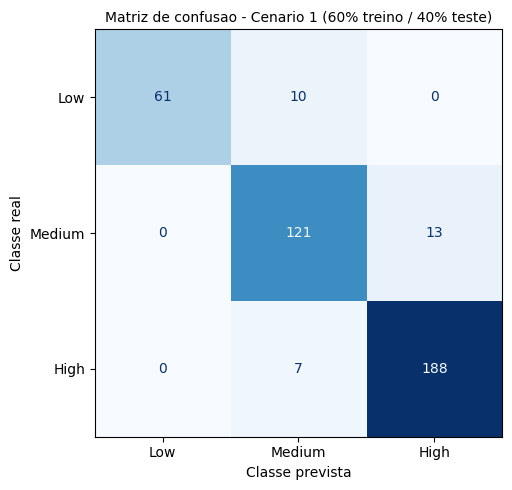

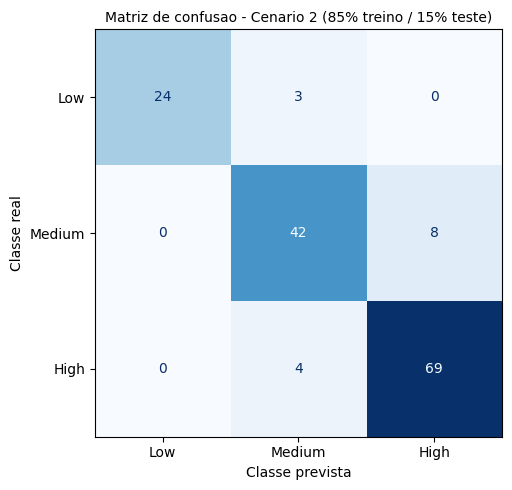


Metricas:
 Cenario               Cenario 1 (60/40)  Cenario 2 (85/15)
Treino                         600.0000           850.0000
Teste                          400.0000           150.0000
Acuracia                         0.9250             0.9000
Precisao (macro)                 0.9374             0.9177
Recall (macro)                   0.9087             0.8914
Precisao (ponderada)             0.9272             0.9018
Recall (ponderado)               0.9250             0.9000

Por classe:
           Cenario Classe  Precisao  Recall     F1  Suporte
Cenario 1 (60/40)    Low    1.0000  0.8592 0.9242     71.0
Cenario 1 (60/40) Medium    0.8768  0.9030 0.8897    134.0
Cenario 1 (60/40)   High    0.9353  0.9641 0.9495    195.0
Cenario 2 (85/15)    Low    1.0000  0.8889 0.9412     27.0
Cenario 2 (85/15) Medium    0.8571  0.8400 0.8485     50.0
Cenario 2 (85/15)   High    0.8961  0.9452 0.9200     73.0


In [13]:
# 03) AVALIACAO
for cm, tit, arq in [(cm1, "Matriz de confusao - Cenario 1 (60% treino / 40% teste)", "figuras/06_confusao_cenario1.png"),
                     (cm2, "Matriz de confusao - Cenario 2 (85% treino / 15% teste)", "figuras/07_confusao_cenario2.png")]:
    fig, ax = plt.subplots(figsize=(5.5, 5))
    ConfusionMatrixDisplay(cm, display_labels=["Low", "Medium", "High"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(tit, fontsize=10)
    ax.set_xlabel("Classe prevista")
    ax.set_ylabel("Classe real")
    plt.tight_layout()
    plt.savefig(arq, dpi=150)
    plt.show()

met = pd.DataFrame([res1, res2]).set_index("Cenario")
met.round(4).to_csv("resultados/metricas_comparativo.csv")
print("\nMetricas:\n", met.round(4).T)

por_classe = []
for nome, rel in [("Cenario 1 (60/40)", rel1), ("Cenario 2 (85/15)", rel2)]:
    for c in ["Low", "Medium", "High"]:
        por_classe.append({"Cenario": nome, "Classe": c, "Precisao": rel[c]["precision"], "Recall": rel[c]["recall"],
                           "F1": rel[c]["f1-score"], "Suporte": rel[c]["support"]})
pc = pd.DataFrame(por_classe)
pc.round(4).to_csv("resultados/metricas_por_classe.csv", index=False)
print("\nPor classe:\n", pc.round(4).to_string(index=False))



| Métrica | Cenário 1 (60/40) | Cenário 2 (85/15) |
|---|---|---|
| Acurácia | **0,9250** | 0,9000 |
| Precisão (macro) | **0,9374** | 0,9177 |
| Recall (macro) | **0,9087** | 0,8914 |

## c) O desempenho é adequado?
**Sim, para este problema o desempenho é adequado** (≈ 90–92,5%), e muito superior ao baseline de 48,6% (sempre prever "High").

* **Os erros são "vizinhos":** não há nenhum Low classificado como High nem High como Low; todos os erros ocorrem entre classes adjacentes (Low→Medium, Medium↔High). Isso é coerente com a natureza ordinal do alvo — as fronteiras entre faixas contíguas é que são difíceis.
* **Precisão da classe Low = 1,00** nos dois cenários: tudo o que o modelo chama de Low realmente é Low. O custo está no **recall de Low (0,86 e 0,89)**: parte da produção baixa é rotulada Medium. Se o objetivo for detectar produção baixa (alerta operacional), esse é o ponto a melhorar.
* **Medium é a classe mais difícil** (F1 0,89 e 0,85), por estar entre as duas outras.
* **Limites:** é um dataset pequeno (1000 amostras) e possivelmente sintético; um modelo linear não captura interações não lineares. Se o custo de errar for alto, vale testar modelos não lineares e calibrar limiares.

## d) Comparação 40% × 15% de teste
O Cenário 1 aparenta ser melhor (+2,5 p.p. de acurácia, +1,97 p.p. de precisão macro, +1,73 p.p. de recall macro), mas **essa diferença não indica que treinar com menos dados seja melhor**: o Cenário 2 tem mais dados de treino (850 contra 600) e, em tese, geraria um modelo igual ou melhor. A diferença observada vem do **acaso da amostra de teste**. Prova: repetindo as duas divisões em **200 partições aleatórias**, a acurácia média é praticamente igual (≈ 0,915 em ambos), mas a dispersão é bem diferente:


| Teste | Média | Desvio | Mín | Máx |
|---|---|---|---|---|
| 40% | 0,9149 | 0,0127 | 0,8850 | 0,9475 |
| 15% | 0,9166 | 0,0222 | 0,8667 | 0,9733 |

Ou seja, com 15% de teste a acurácia de uma única divisão pode variar de ~87% a ~97%, enquanto com 40% fica entre ~89% e ~95%.

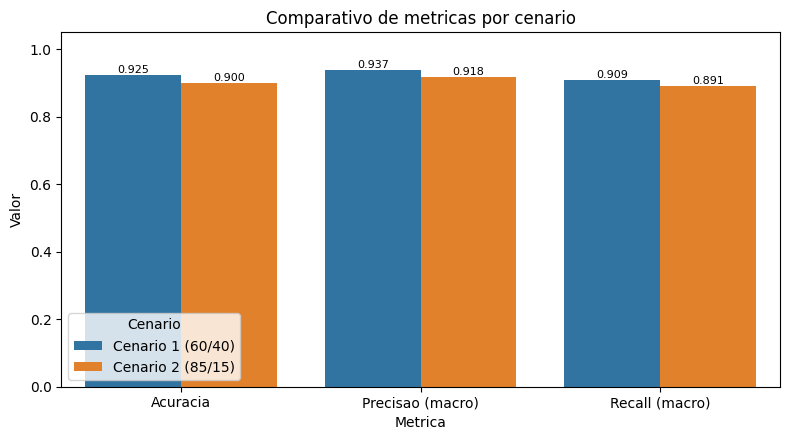

In [14]:
plot = met[["Acuracia", "Precisao (macro)", "Recall (macro)"]].reset_index().melt(
    id_vars="Cenario", var_name="Metrica", value_name="Valor")
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(data=plot, x="Metrica", y="Valor", hue="Cenario")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8)
plt.ylim(0, 1.05)
plt.title("Comparativo de metricas por cenario")
plt.tight_layout()
plt.savefig("figuras/08_comparativo_metricas.png", dpi=150)
plt.show()


Variabilidade (200 particoes):
 Teste  Media  Desvio    Min    Max
  40% 0.9149  0.0127 0.8850 0.9475
  15% 0.9166  0.0222 0.8667 0.9733


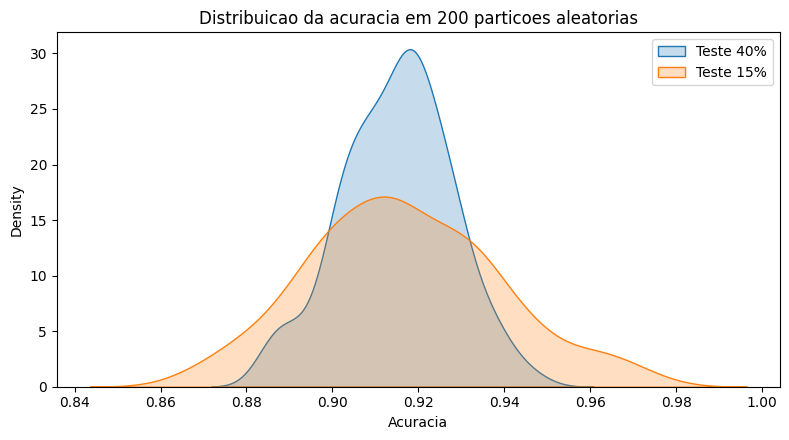

In [15]:
# Variabilidade da estimativa: 200 particoes aleatorias para cada tamanho de teste
def distrib(test_size, n=200):
    accs = []
    for i in range(n):
        Xtr, Xte, ytr, yte = train_test_split(df[FEATURES], df["Energy_Class_enc"], test_size=test_size,
                                              random_state=1000 + i, stratify=df["Energy_Class_enc"])
        p = Pipeline([("sc", StandardScaler()), ("m", LogisticRegression(max_iter=5000))]).fit(Xtr, ytr)
        accs.append(accuracy_score(yte, p.predict(Xte)))
    return np.array(accs)


a40, a15 = distrib(0.40), distrib(0.15)
var = pd.DataFrame({"Teste": ["40%", "15%"], "Media": [a40.mean(), a15.mean()], "Desvio": [a40.std(), a15.std()],
                    "Min": [a40.min(), a15.min()], "Max": [a40.max(), a15.max()]})
var.round(4).to_csv("resultados/variabilidade_200_particoes.csv", index=False)
print("\nVariabilidade (200 particoes):\n", var.round(4).to_string(index=False))
plt.figure(figsize=(8, 4.5))
sns.kdeplot(a40, fill=True, label="Teste 40%")
sns.kdeplot(a15, fill=True, label="Teste 15%")
plt.xlabel("Acuracia")
plt.title("Distribuicao da acuracia em 200 particoes aleatorias")
plt.legend()
plt.tight_layout()
plt.savefig("figuras/09_variabilidade_acuracia.png", dpi=150)
plt.show()

In [16]:
print("\nConcluido.")


Concluido.


## e) Vantagens e limitações de um conjunto de teste maior ou menor

**Teste maior (40%)**
* **Avaliação mais confiável:** o erro-padrão da acurácia é ≈ √(p(1−p)/n); com n = 400 é ≈ 1,4 p.p. e o IC 95% ≈ ±2,8 p.p. Todas as classes (inclusive Low) têm mais exemplos de teste (71 contra 27), então precisão/recall por classe são menos instáveis.
* **Menos dados para treinar** (600): o modelo pode ficar um pouco pior do que poderia, e a métrica tende a ser levemente pessimista em relação ao modelo final treinado com tudo. Em modelos mais complexos ou com mais features, isso pesa mais.

**Teste menor (15%)**
* **Mais dados para treinar** (850): estimativa dos coeficientes mais estável, útil quando os dados são escassos ou o modelo é complexo.
* **Avaliação mais ruidosa:** com n = 150, o erro-padrão é ≈ 2,3 p.p. e o IC 95% ≈ ±4,5 p.p.; cada erro vale 0,67 p.p. de acurácia. A classe Low tem só 27 exemplos de teste, então o recall de Low varia muito com 1 ou 2 casos. A diferença de 2,5 p.p. entre os cenários cabe nesse intervalo de ruído.

**Compromisso (*trade-off*):** mais treino reduz o *viés* do modelo, mais teste reduz a *variância* da estimativa de desempenho. Como o dataset é pequeno, a boa prática é complementar a divisão simples com **validação cruzada estratificada** (aqui: 0,9167 ± 0,0198) para obter uma estimativa estável e usar todo o dado para treinar o modelo final.

---
## Conclusão geral
1. Só `Efficiency_Ratio` correlaciona com o alvo, mas o Pearson o subestima por causa de outliers; Spearman e a transformação log revelam a relação real.
2. Foi selecionado um subconjunto de 4 features, justificado por correlação, ablação e validação cruzada.
3. A Regressão Logística (modelo linear) atingiu **92,5%** (60/40) e **90,0%** (85/15) de acurácia, com erros apenas entre classes adjacentes.
4. A diferença entre cenários é explicada pela variância da amostra de teste, não por uma superioridade real: o desempenho esperado do modelo é ≈ **91–92%**.